In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sb
import numpy as np
import matplotlib
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import (Dropout, Conv1D, MaxPooling1D, BatchNormalization, 
                    Flatten, Dense, Layer, LSTM, Bidirectional)
from tensorflow.keras.models import Sequential
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import (classification_report, accuracy_score, mean_squared_error, 
confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_score)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from math import sqrt
import time
import warnings
warnings.filterwarnings('ignore')
from tensorflow.keras import regularizers
matplotlib.rcParams["figure.figsize"] = (6, 4)
plt.style.use("ggplot")
plt.rcParams['axes.grid'] = False

# df.to_csv('path/to/dataset.csv', index=False) # From xlsx to csv

### Load the dataset

In [2]:
df = pd.read_csv('data/23March2025_feeds.csv')

In [3]:
# df = pd.read_excel('data/23March2025_feeds.xlsx')
# df = df.to_csv('data/1_23March2025_feeds.csv', index=False) # From xlsx to csv

In [4]:
df = df.drop(columns=['entry_id', 'latitude', 'longitude', 'elevation', 'status'])

### Dataset organisation

In [5]:
df['date'] = pd.to_datetime(df['created_at'])

In [6]:
df['time'] = (df['date'] - df['date'].min()).dt.total_seconds() #/ (24 * 3600
df['days'] = (df['date'] - df['date'].min()).dt.total_seconds() / (24 * 3600) #/ 
df['time'] = df['time'].apply(lambda x: round(x, 4))
df.loc[df.index[0], 'time'] = 0
df.loc[df.index[0], 'days'] = 0

In [7]:
# df.set_index('date', inplace=True)
df = df.drop(columns=['created_at'])

In [8]:
# df = df[(df >= 0).all(axis=1)]

In [9]:
df = df.rename(columns = {'field1':'vibration', 'field2':'temperature', 
                            'field3':'back_pressure', 'field4':'sepam_current',
                           'field5':'sepam_voltage', 'field6':'exciter_current',
                           'field7':'speed', 'field8':'blade_position'})

### Cycle breaking point

#### With 0.5 limit, we got irregular intervals and the traditional
#### time models struggle to handle it. In order to bypass that issue, we resample the target in group of 
#### hour, day, month, etc. or in groupe

In [10]:
df['labels_vib'] = df['vibration'].apply(lambda x: 1 if x < 0.28 or x > 1.12 else 0) #StandardISO
# df['labels_vib'] = df['vibration'].apply(lambda x: 1 if x > 0.35 else 0) #Average

In [11]:
num_outliers = df['labels_vib'].value_counts().get(1, 0)  # Get the count of 1s, default to 0 if not found
print(f'Number of outliers/anomalies: {num_outliers}')

Number of outliers/anomalies: 79108


#### Get cycles with labels

In [12]:
# Check if 'labels' column exists
if 'labels_vib' not in df.columns:
    raise ValueError("The 'labels' column is not present in the Excel file.")

# Initialize the cycle column
cycle_number = 1
cycle_column = []

# Iterate through the labels column
for i, label in enumerate(df['labels_vib']):
    cycle_column.append(cycle_number)
    if label == 1:
        cycle_number += 1

# Assign the cycle column to the DataFrame
df['cycle_vib'] = cycle_column

In [13]:
df['rul'] = df.groupby('cycle_vib')['days'].transform('max') - df['days']

In [14]:
max_cycle = df['cycle_vib'].max()
print(f"The maximum cycle in the DataFrame is: {max_cycle}")

The maximum cycle in the DataFrame is: 79109


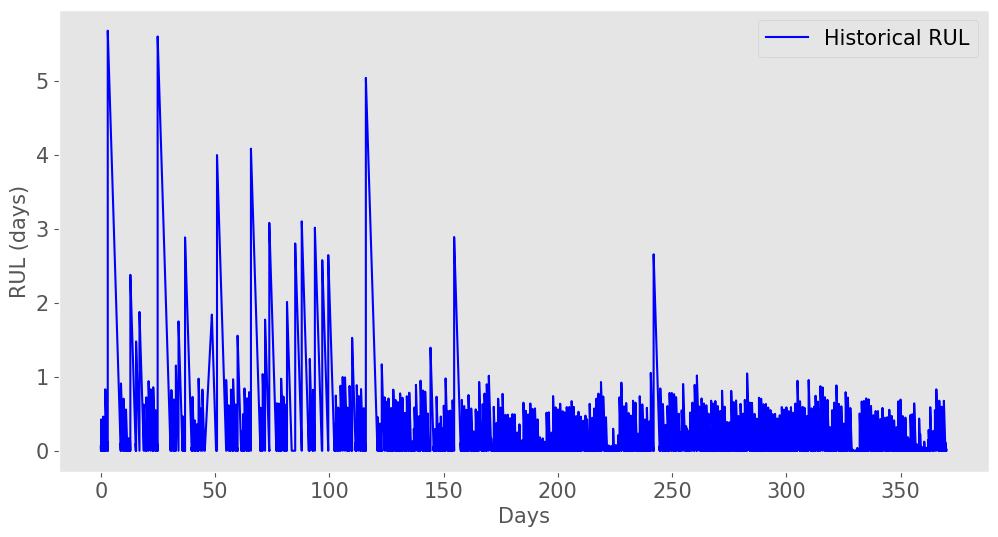

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(df['days'], df['rul'], color='blue', label='Historical RUL')
# plt.plot(cnn_y_pred[0:237], color='purple', label='Predicted')
plt.ylabel('RUL (days)', size = 15)
plt.xlabel('Days', size = 15)
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.legend(fontsize=15)
plt.show()

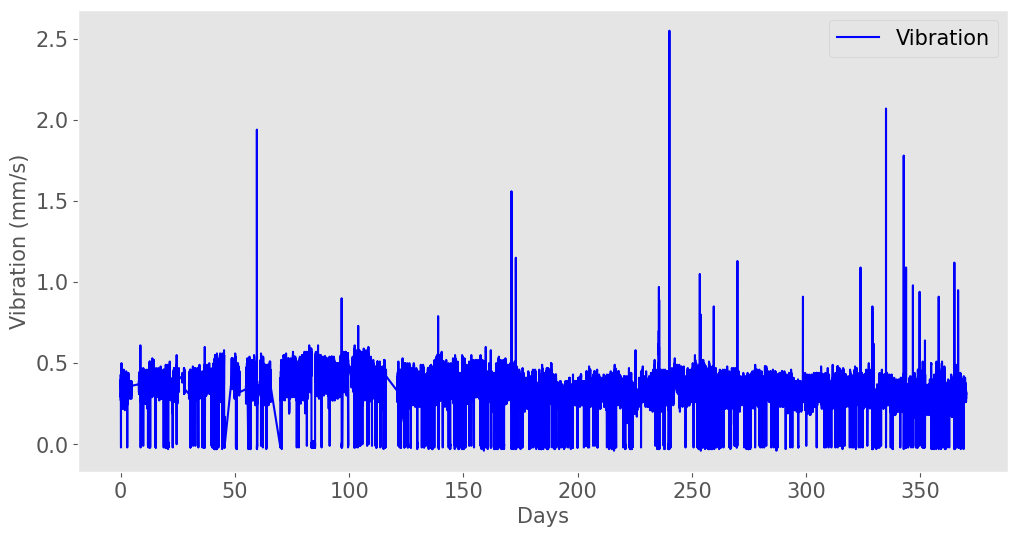

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(df['days'], df['vibration'], color='blue', label='Vibration')
# plt.plot(cnn_y_pred[0:237], color='purple', label='Predicted')
plt.ylabel('Vibration (mm/s)', size = 15)
plt.xlabel('Days', size = 15)
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.legend(fontsize = 15)
plt.show()

In [99]:
df.describe()

,vibration,temperature,back_pressure,sepam_current,sepam_voltage,exciter_current,speed,blade_position,time,days,labels_vib,cycle_vib,rul
count,482942.000000,482942.000000,482942.000000,482942.000000,482942.000000,482942.000000,482942.000000,482942.000000,4.829420e+05,482942.000000,482942.000000,482942.000000,482942.000000
mean,0.332147,47.937414,7.423764,227.249193,238.448564,0.741216,956.560800,53.138111,1.681034e+07,194.564103,0.163804,29506.869560,0.341397
std,0.097222,6.413252,1.433891,114.192355,116.438708,0.223822,202.584857,21.151964,9.093428e+06,105.248014,0.370098,22540.389373,0.540930
min,-0.040000,21.600000,0.140000,0.000000,0.000000,0.000000,0.000000,-0.650000,0.000000e+00,0.000000,0.000000,1.000000,0.000000
25%,0.300000,44.100000,7.660000,162.400000,173.600000,0.670000,997.000000,43.430000,9.291705e+06,107.542882,0.000000,8537.000000,0.008299
50%,0.350000,46.400000,7.750000,197.500000,209.800000,0.720000,1000.000000,49.410000,1.705060e+07,197.344850,0.000000,27018.000000,0.168137
75%,0.380000,49.900000,7.810000,268.800000,279.400000,0.800000,1003.000000,59.330000,2.467224e+07,285.558356,0.000000,47044.000000,0.451516
max,2.550000,70.200000,9.080000,535.900000,546.600000,2.880000,1623.000000,103.990000,3.196520e+07,369.967593,1.000000,79109.000000,5.673958


In [100]:
cols_corr = ['vibration', 'temperature', 'back_pressure', 'sepam_current', 'sepam_voltage', 
             'exciter_current', 'speed', 'blade_position', 'rul']

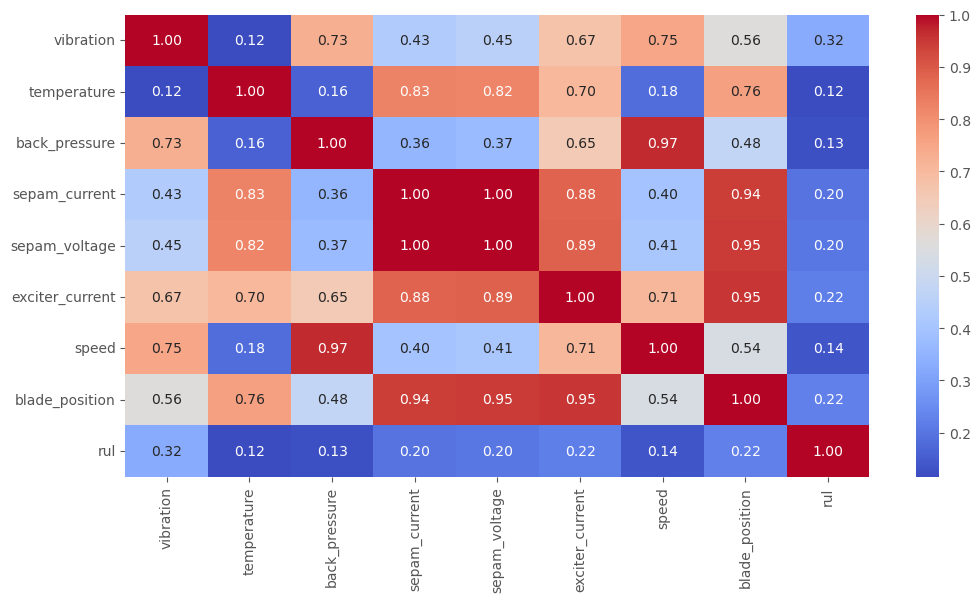

In [101]:
plt.figure(figsize=(12, 6))  
dataplot = sb.heatmap(df[cols_corr].corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

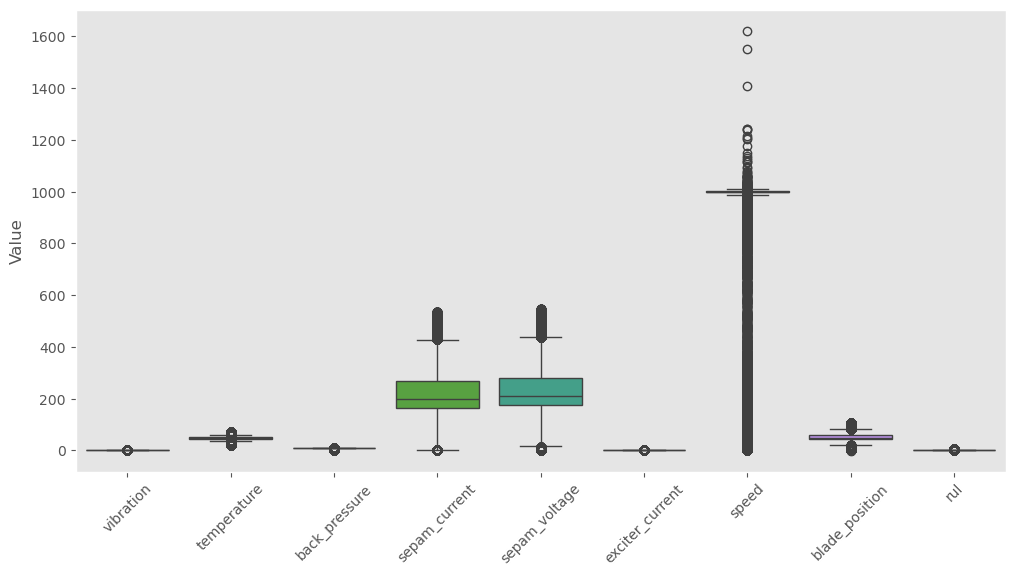

In [102]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[cols_corr])
# plt.title("Features Distribution")
plt.xticks(rotation=45)
plt.ylabel('Value')
plt.show()

### Features and target && Data transformation

In [103]:
cycle_counts = df['cycle_vib'].value_counts()
longest_cycle = cycle_counts.idxmax()
num_items = cycle_counts.max()
print(f"Longest cycle: {longest_cycle}, Number of items: {num_items}")

Longest cycle: 5430, Number of items: 4425


In [104]:
# cycle_dfs = {cycle: df[df['cycle_vib'] == cycle] for cycle in df['cycle_vib'].unique()}

# cycle1 = cycle_dfs.get(1)  # get cycle 1
# cycle2 = cycle_dfs.get(2)
# cycle3 = cycle_dfs.get(3)
# train = pd.concat([cycle1, cycle2, cycle3])
# # val = cycle_dfs.get(2)  # get cycle 2
# test = cycle_dfs.get(4)  # get cycle 3

In [105]:
df.columns

Index(['vibration', 'temperature', 'back_pressure', 'sepam_current',
       'sepam_voltage', 'exciter_current', 'speed', 'blade_position', 'date',
       'time', 'days', 'labels_vib', 'cycle_vib', 'rul'],
      dtype='object')

In [106]:
col_skew = ['vibration', 'temperature', 'back_pressure', 'sepam_current',
       'sepam_voltage', 'exciter_current', 'speed', 'blade_position', 'rul']

In [107]:
# find skewness in each row 
df[col_skew].skew(axis = 0, skipna = True) #axis = 1

vibration         -1.660051
temperature        1.029999
back_pressure     -4.498191
sepam_current      0.857870
sepam_voltage      0.800574
exciter_current   -0.844078
speed             -4.469607
blade_position     0.417505
rul                3.668178
dtype: float64

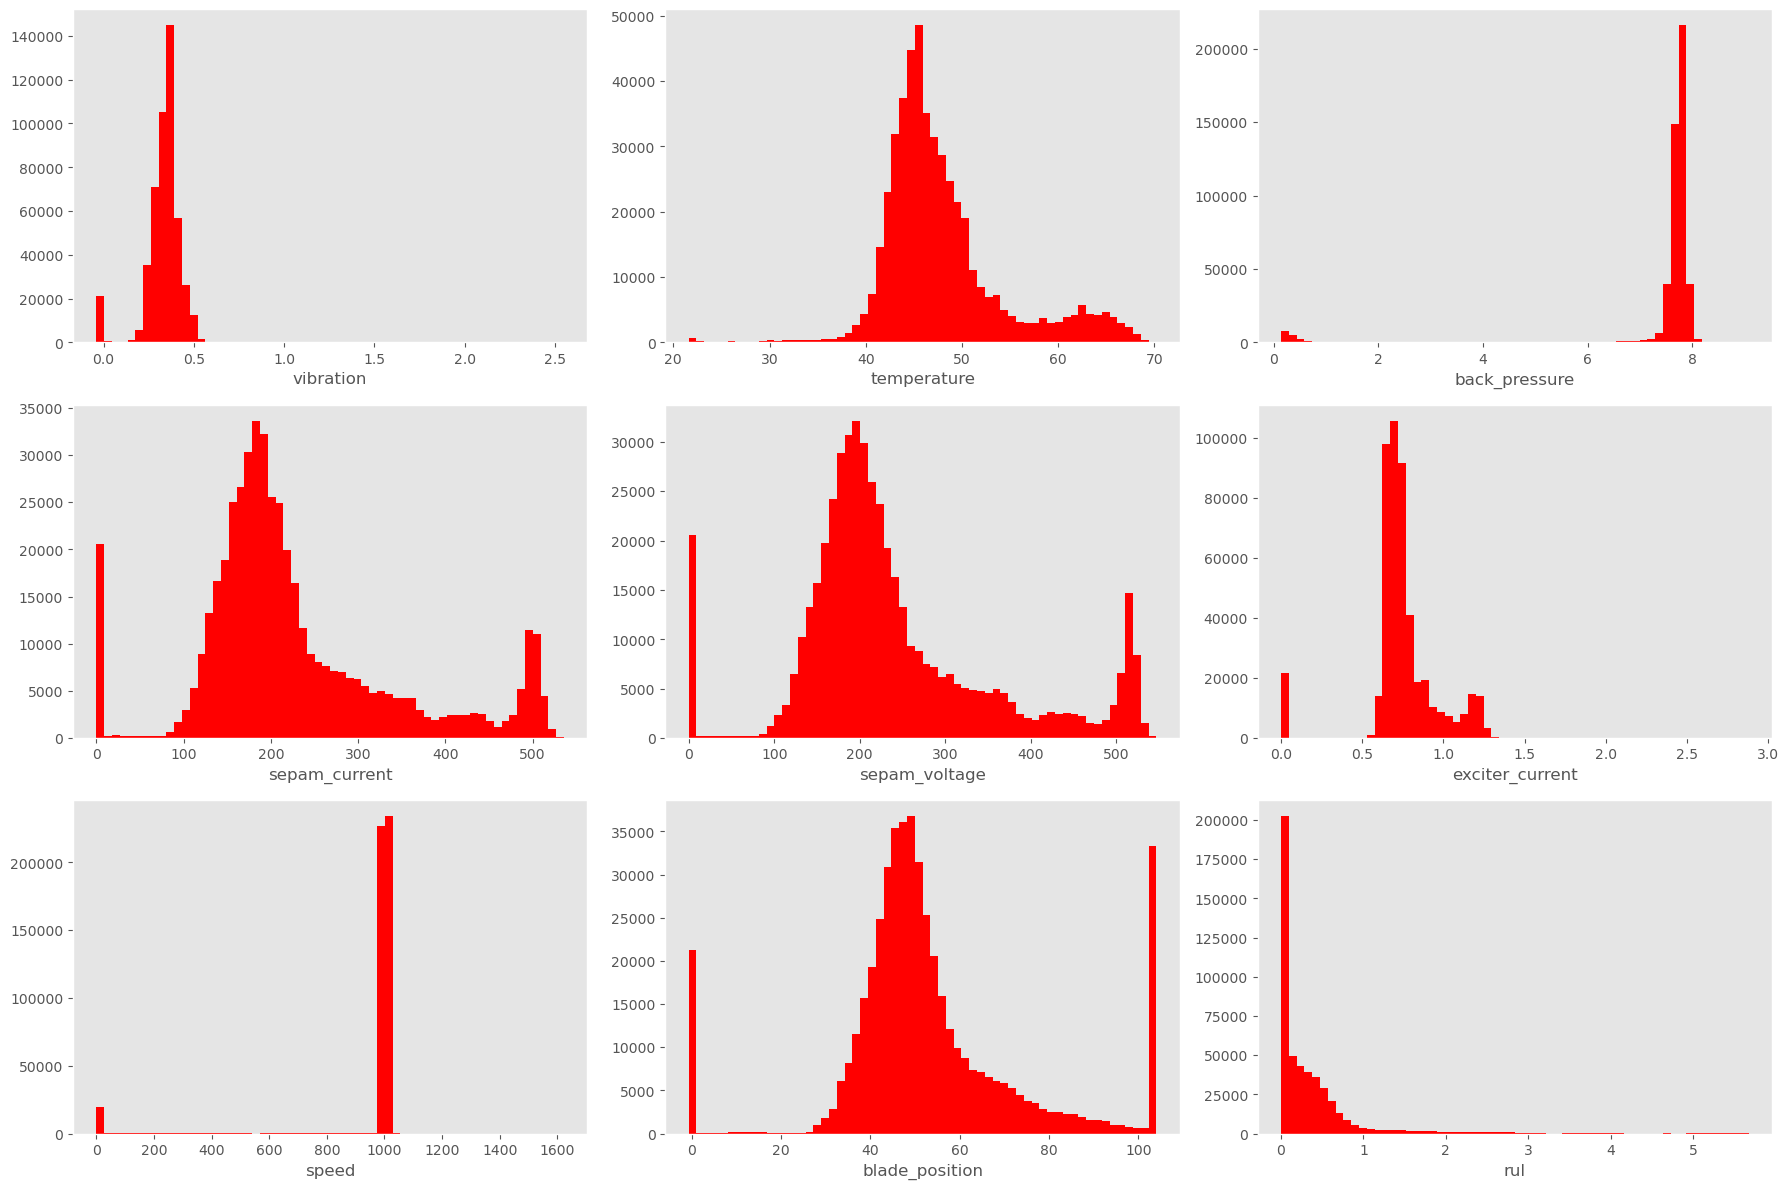

In [108]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
axes = axes.flatten()  # Flatten to easily index with a single loop

# # List of the 8 column names to plot
# columns = ['vibration', 'temperature', 'back_pressure', 'sepam_current',
#            'column5', 'column6', 'column7', 'column8']  # Replace with actual column names

# Plot each histogram
for i, col in enumerate(col_skew):
    axes[i].hist(df[col], bins=60, color='r')
    axes[i].set_xlabel(col)
    # axes[i].set_title(f'Histogram of {col}')

plt.tight_layout()
plt.show()

In [109]:
# fig, (ax1, ax2, ax3, ax4) = plt.subplots(ncols = 4, figsize =(20, 5))

# ax1.hist(df['vibration'], bins=60, color ='r')
# ax1.set_xlabel('Vibration')
# ax2.hist(df['temperature'], bins=60, color ='r')
# ax2.set_xlabel('Temperature')
# ax3.hist(df['back_pressure'], bins=60, color ='r')
# ax3.set_xlabel('Back pressure')
# ax4.hist(df['sepam_current'], bins=60, color ='r')
# ax4.set_xlabel('Sepam current')

# plt.show()

In [110]:
from sklearn.preprocessing import PowerTransformer

trf1 = FunctionTransformer(func=np.square)
trf2 = FunctionTransformer(func=np.sqrt) #first
trf3 = FunctionTransformer(func=np.log1p)
trf4 = PowerTransformer(method='yeo-johnson')

In [111]:
# print(((df[cols_log] < 0).sum()), ((df[cols_yeo] <= 0).sum()))

In [112]:
# Apply transformations like log1p, sqrt, or boxcox.

cols_log=['temperature', 'sepam_current', 'sepam_voltage', 'exciter_current', 'blade_position']
df[cols_log] = pd.DataFrame(trf2.fit_transform(df[cols_log]), columns=cols_log, index=df.index)
df[cols_log] = df[cols_log].fillna(0)

# Apply transformations like Consider log, reciprocal, or yeo-johnson transformations.

cols_yeo=['back_pressure', 'speed']
df[cols_yeo] = pd.DataFrame(trf4.fit_transform(df[cols_yeo]), columns=cols_yeo, index=df.index)

# df.rename(columns={df.columns[0]: 'back_pressure', df.columns[1]: 'speed'}, inplace=True)

df.rename(columns={'0': 'back_pressure', '1': 'speed'}, inplace=True)
df[cols_yeo] = df[cols_yeo].fillna(0)

df['rul'] = pd.DataFrame(trf4.fit_transform(df[['rul']]), columns=['rul'], index=df.index)
df['rul'] = df['rul'].fillna(0)

In [113]:
df[col_skew].skew(axis = 0, skipna = True) #axis = 1

vibration         -1.660051
temperature        0.682272
back_pressure     -2.446018
sepam_current     -0.976693
sepam_voltage     -1.082370
exciter_current   -3.098189
speed             -4.345071
blade_position    -1.879304
rul                0.331262
dtype: float64

In [114]:
print(df.isna().sum())
# print(df['rul'].isna().sum())

vibration          0
temperature        0
back_pressure      0
sepam_current      0
sepam_voltage      0
exciter_current    0
speed              0
blade_position     0
date               0
time               0
days               0
labels_vib         0
cycle_vib          0
rul                0
dtype: int64


In [115]:
df = df.dropna()

In [116]:
print(df.isna().sum())

vibration          0
temperature        0
back_pressure      0
sepam_current      0
sepam_voltage      0
exciter_current    0
speed              0
blade_position     0
date               0
time               0
days               0
labels_vib         0
cycle_vib          0
rul                0
dtype: int64


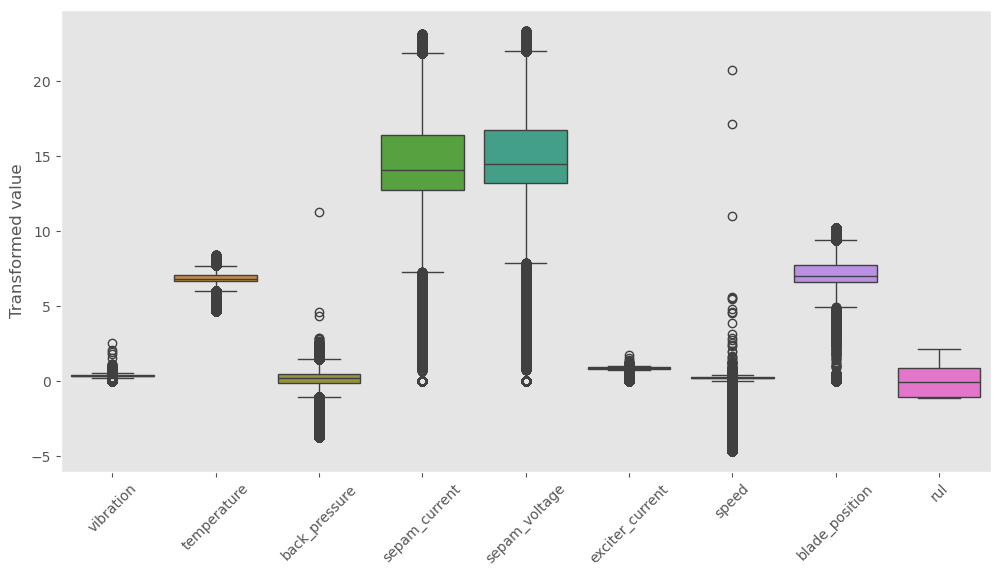

In [117]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[cols_corr])
# plt.title("Features Distribution")
plt.xticks(rotation=45)
plt.ylabel('Transformed value')
plt.show()

In [118]:
cols_desc=['vibration', 'temperature', 'back_pressure', 'sepam_current',
       'sepam_voltage', 'exciter_current', 'speed', 'blade_position', 'rul']

In [119]:
# df[cols_desc].describe()

In [120]:
cols_features=['vibration', 'temperature', 'back_pressure', 'sepam_current', 'sepam_voltage', 
             'exciter_current', 'speed', 'blade_position', 'days']

In [121]:
X = df[cols_features]
y = df[['rul', 'days']]

In [122]:
X.set_index('days', inplace=True)
y.set_index('days', inplace=True)

In [123]:
# trf1 = FunctionTransformer(func=np.square)
# trf2 = FunctionTransformer(func=np.sqrt)
# trf3 = FunctionTransformer(func=np.log1p)
# X = pd.DataFrame(trf1.fit_transform(X))
# X.fillna(0, inplace=True)
# X = pd.DataFrame(trf2.fit_transform(X))
# X.fillna(0, inplace=True)
# X = pd.DataFrame(trf3.fit_transform(X))
# y = pd.DataFrame(trf3.fit_transform(y))
# X.fillna(0, inplace=True)
# y.fillna(0, inplace=True)

In [124]:
tscv = TimeSeriesSplit(n_splits=3)
for i, (train_index, test_index) in enumerate(tscv.split(X)):
    X_train1, X_test1 = X.iloc[train_index,:], X.iloc[test_index,:]
    y_train1, y_test1 = y.iloc[train_index], y.iloc[test_index]
    df_train, df_test = df.iloc[train_index], df.iloc[test_index]

In [125]:
scaler = StandardScaler()
scaler_target = StandardScaler()

scaler.fit(X_train1)
scaler_target.fit(y_train1)

X_train_scaled = pd.DataFrame(scaler.transform(X_train1), columns=X_train1.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test1), columns=X_test1.columns)
y_train_scaled = pd.DataFrame(scaler_target.transform(y_train1), columns=y_train1.columns)
y_test_scaled = pd.DataFrame(scaler_target.transform(y_test1), columns=y_test1.columns, index=y_test1.index)

In [126]:
def create_dataset(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X.iloc[i:(i + time_steps)]
        Xs.append(v)        
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)

In [127]:
TIME_STEPS = 120 # 1,400 seconds = 1 day used to perform 3 days prediction 4320
# Use 7 days = 60 * 24 * 7 = 10080 to predict 3 days = 60 * 24 * 3 = 4320
X_train, y_train = create_dataset(X_train_scaled, y_train_scaled, TIME_STEPS)
X_test, y_test = create_dataset(X_test_scaled, y_test_scaled, TIME_STEPS)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(362087, 120, 8) (362087, 1)
(120615, 120, 8) (120615, 1)


### CNN

In [128]:
from tensorflow.keras.layers import TimeDistributed

In [129]:
cnn_model = Sequential()
#(32, 64, 10, 2 layers)
cnn_model.add(Conv1D(filters=128, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]))) 
cnn_model.add(Conv1D(filters=64, kernel_size=7, activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(Dropout(0.2))
cnn_model.add(Flatten())
cnn_model.add(Dense(50, activation='tanh', kernel_regularizer=regularizers.l2(0.001)))
cnn_model.add(Dense(120)) #One day prediction(1) #,activation='linear'

optimizer = keras.optimizers.Adam(0.0005)
cnn_model.compile(loss='mse', optimizer=optimizer, metrics=['mae'])
cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)               │ (None, 118, 128)       │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 112, 64)        │        57,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 112, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 7168)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 50)             │       358,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 120)            │         6,120 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 425,434 (1.62 MB)

 Trainable params: 425,306 (1.62 MB)

 Non-trainable params: 128 (512.00 B)

In [130]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
ts = time.time()
cnn_history = cnn_model.fit(
                    X_train, 
                    y_train, 
                    epochs=50, 
                    batch_size=32, 
                    validation_split=0.1,
                    callbacks=[early_stopping]
                    )
print("Training time:", time.time() - ts)

Epoch 1/50
10184/10184 ━━━━━━━━━━━━━━━━━━━━ 127s 12ms/step - loss: 0.5658 - mae: 0.5433 - val_loss: 0.4114 - val_mae: 0.4267
Epoch 2/50
10184/10184 ━━━━━━━━━━━━━━━━━━━━ 163s 16ms/step - loss: 0.4516 - mae: 0.4652 - val_loss: 0.3688 - val_mae: 0.3829
Epoch 3/50
10184/10184 ━━━━━━━━━━━━━━━━━━━━ 165s 16ms/step - loss: 0.3988 - mae: 0.4293 - val_loss: 0.3546 - val_mae: 0.3735
Epoch 4/50
10184/10184 ━━━━━━━━━━━━━━━━━━━━ 172s 17ms/step - loss: 0.3637 - mae: 0.4042 - val_loss: 0.4018 - val_mae: 0.4040
Epoch 5/50
10184/10184 ━━━━━━━━━━━━━━━━━━━━ 142s 14ms/step - loss: 0.3339 - mae: 0.3828 - val_loss: 0.4086 - val_mae: 0.4255
Epoch 6/50
10184/10184 ━━━━━━━━━━━━━━━━━━━━ 131s 13ms/step - loss: 0.3058 - mae: 0.3630 - val_loss: 0.4431 - val_mae: 0.4242
Epoch 7/50
10184/10184 ━━━━━━━━━━━━━━━━━━━━ 127s 12ms/step - loss: 0.2838 - mae: 0.3474 - val_loss: 0.4732 - val_mae: 0.4434
Epoch 8/50
10184/10184 ━━━━━━━━━━━━━━━━━━━━ 126s 12ms/step - loss: 0.2712 - mae: 0.3377 - val_loss: 0.4610 - val_mae: 0.4288


In [131]:
cnn_y_pred = cnn_model.predict(X_test)
cnn_y_pred_train = cnn_model.predict(X_train)

3770/3770 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step
11316/11316 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step


### Model validation on test set - CNN

In [132]:
true_vals = y_test[3000:9001, 0]       # Shape: [6001]
pred_vals = cnn_y_pred[3000:9001, 0]   # Shape: [6001]

# Compute metrics
mse = mean_squared_error(true_vals, pred_vals)
mae = mean_absolute_error(true_vals, pred_vals)
rmse = np.sqrt(mse)
r2_cnn = r2_score(true_vals, pred_vals)

print(f"Second Output Metrics:")
print("-----------------------------------")
print(f"MSE: {mse:.4f}")
print("-----------------------------------")
print(f"MAE: {mae:.4f}")
print("-----------------------------------")
print(f"RMSE: {rmse:.4f}")
print("-----------------------------------")
print(f"Test R² Score: {r2_cnn:.4f}") #0.1399

Second Output Metrics:
-----------------------------------
MSE: 0.2288
-----------------------------------
MAE: 0.3461
-----------------------------------
RMSE: 0.4783
-----------------------------------
Test R² Score: 0.6882


In [133]:
# Make sure true_vals and pred_vals have shape (n_samples, 120)
true_vals = y_test[3000:9001, :]       # shape: (6001, 120)
pred_vals = cnn_y_pred[3000:9001, :]   # shape: (6001, 120)

# Per-output MSE, MAE, RMSE
mse_per_output = np.mean((true_vals - pred_vals) ** 2, axis=0)
mae_per_output = np.mean(np.abs(true_vals - pred_vals), axis=0)
rmse_per_output = np.sqrt(mse_per_output)

# R2 score per output
r2_per_output = [r2_score(true_vals[:, i], pred_vals[:, i]) for i in range(true_vals.shape[1])]

# Average metrics across all outputs
mse_cnn = mse_per_output.mean()
mae_cnn = mae_per_output.mean()
rmse_cnn = rmse_per_output.mean()
r2_cnn = np.mean(r2_per_output)

# Print summary
print(f"Average MSE: {mse_cnn:.4f}")
print("-----------------------------------")
print(f"Average MAE: {mae_cnn:.4f}")
print("-----------------------------------")
print(f"Average RMSE: {rmse_cnn:.4f}")
print("-----------------------------------")
print(f"Average R²: {r2_cnn:.4f}")

Average MSE: 0.2290
-----------------------------------
Average MAE: 0.3464
-----------------------------------
Average RMSE: 0.4786
-----------------------------------
Average R²: 0.6882


### Plots - CNN

In [134]:
days_train = df['days'].iloc[:len(y_train)]
days_test = df['days'].iloc[len(y_train):len(y_train) + len(y_test)]

In [135]:
inv1 = pd.DataFrame(trf4.inverse_transform(df['rul'].values.reshape(-1, 1)))

In [136]:
train_inv1 = inv1.iloc[:len(y_train)]
test_inv1  = inv1.iloc[len(y_train):len(y_train) + len(y_test)]

In [137]:
# First transformer
y_pred_inve = np.zeros_like(cnn_y_pred)
for i in range(cnn_y_pred.shape[1]):
    y_pred_inve[:, i] = scaler_target.inverse_transform(cnn_y_pred[:, i].reshape(-1, 1)).flatten()

# Second transformer
y_pred_invee = np.zeros_like(y_pred_inve)
for i in range(y_pred_inve.shape[1]):
    y_pred_invee[:, i] = trf4.inverse_transform(y_pred_inve[:, i].reshape(-1, 1)).flatten()

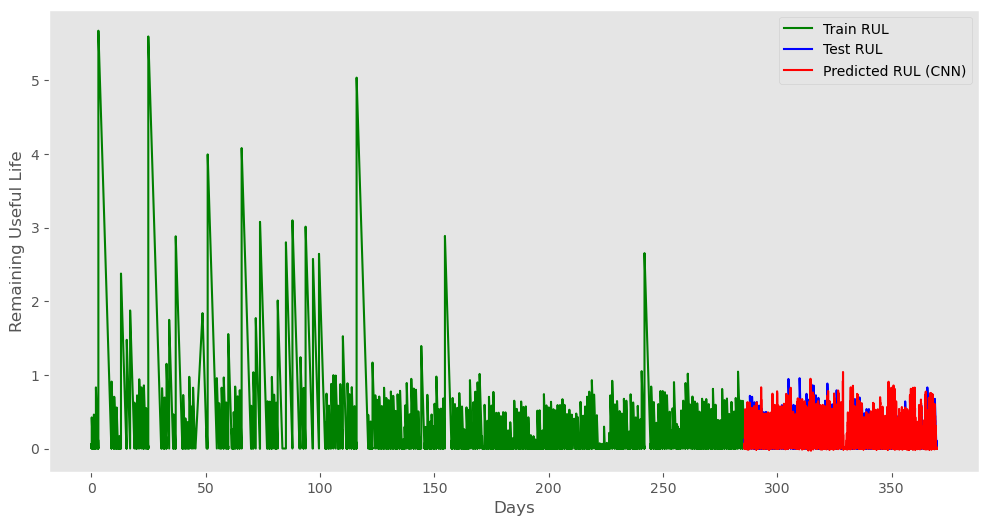

In [138]:
plt.figure(figsize=(12, 6))
plt.plot(days_train, train_inv1, 'g', label="Train RUL")
plt.plot(days_test, test_inv1, 'b', label="Test RUL") # marker='.',
plt.plot(days_test, y_pred_invee[:, 0], 'r', label="Predicted RUL (CNN)")
plt.ylabel('Remaining Useful Life')
plt.xlabel('Days')
plt.legend()
plt.show()

In [139]:
sub_y_pred_invee = pd.DataFrame(y_pred_invee[:, 0])

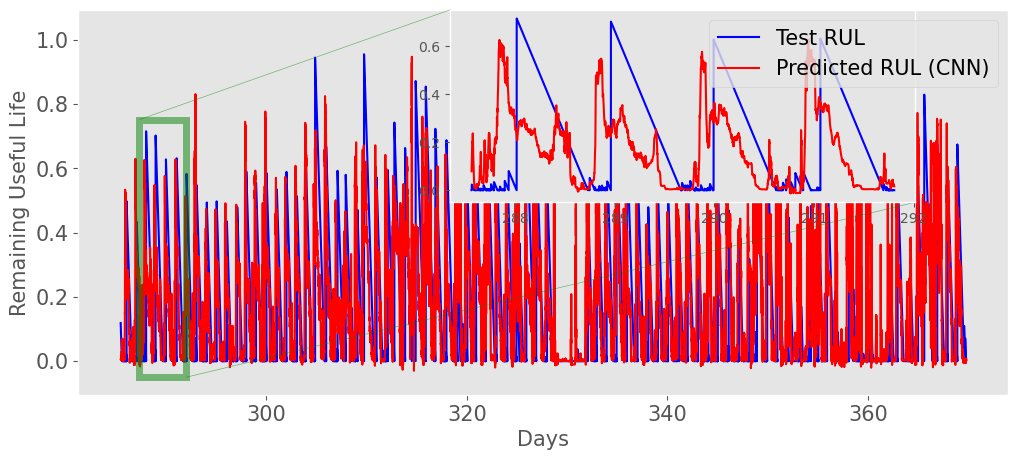

In [140]:
fig, ax = plt.subplots(figsize=(12, 5))

# Main plot
# ax.plot(days_train, train_inv1, color='green', label='Train RUL')
ax.plot(days_test, test_inv1, color='blue', label='Test RUL')
ax.plot(days_test, sub_y_pred_invee, color='red', label='Predicted RUL (CNN)')

# Zoomed-in section on test data only
x_zoom = days_test[3000:9000]
test1 = test_inv1.iloc[3000:9000]
cnn1 = sub_y_pred_invee.iloc[3000:9000]

zm = ax.inset_axes([0.4, 0.5, 0.5, 0.5])
zm.plot(x_zoom, test1, color='blue')
zm.plot(x_zoom, cnn1, color='red')

# Indicate zoomed area correctly on test portion
ax.indicate_inset_zoom(zm, edgecolor='green', lw=5)

plt.xticks(size = 15)
plt.yticks(size = 15)
plt.ylabel('Remaining Useful Life', size = 15)
plt.xlabel('Days', size = 15)
plt.legend(fontsize=15)
plt.show()

## LSTM

In [141]:
lstm_model = Sequential()
lstm_model.add(LSTM(100, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
lstm_model.add(Dropout(0.2)) #0.2
lstm_model.add(LSTM(50, return_sequences=False))
lstm_model.add(Dropout(0.2)) #0.001
lstm_model.add(Dense(25, activation='relu'))
lstm_model.add(Dense(120))  # Sigmoid for probability output # ,activation='linear'
optimizer = keras.optimizers.Adam(0.0001)
lstm_model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])  # Binary classification loss
lstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 120, 100)       │        43,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 120, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 120)            │         3,120 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,195 (305.45 KB)

 Trainable params: 78,195 (305.45 KB)

 Non-trainable params: 0 (0.00 B)

In [142]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
ts = time.time()
lstm_history = lstm_model.fit(
                    X_train, 
                    y_train, 
                    epochs=50, #100
                    batch_size=32, 
                    validation_split=0.1,
                    shuffle=True,
                    callbacks=[early_stopping]
                    )
print("Training time:", time.time() - ts)

Epoch 1/50
10184/10184 ━━━━━━━━━━━━━━━━━━━━ 574s 56ms/step - loss: 0.5904 - mae: 0.5978 - val_loss: 0.3040 - val_mae: 0.3726
Epoch 2/50
10184/10184 ━━━━━━━━━━━━━━━━━━━━ 575s 57ms/step - loss: 0.4465 - mae: 0.4898 - val_loss: 0.3201 - val_mae: 0.3735
Epoch 3/50
10184/10184 ━━━━━━━━━━━━━━━━━━━━ 578s 57ms/step - loss: 0.4064 - mae: 0.4604 - val_loss: 0.3430 - val_mae: 0.3736
Epoch 4/50
10184/10184 ━━━━━━━━━━━━━━━━━━━━ 579s 57ms/step - loss: 0.3729 - mae: 0.4335 - val_loss: 0.3513 - val_mae: 0.3719
Epoch 5/50
10184/10184 ━━━━━━━━━━━━━━━━━━━━ 584s 57ms/step - loss: 0.3346 - mae: 0.4052 - val_loss: 0.3666 - val_mae: 0.3800
Epoch 6/50
10184/10184 ━━━━━━━━━━━━━━━━━━━━ 588s 58ms/step - loss: 0.3054 - mae: 0.3849 - val_loss: 0.3340 - val_mae: 0.3601
Training time: 3496.5576360225677


In [143]:
lstm_y_pred = lstm_model.predict(X_test)
lstm_y_pred_train = lstm_model.predict(X_train)

3770/3770 ━━━━━━━━━━━━━━━━━━━━ 54s 14ms/step
11316/11316 ━━━━━━━━━━━━━━━━━━━━ 165s 15ms/step


### Model validation on test set - LSTM

In [144]:
# Make sure true_vals and pred_vals have shape (n_samples, 120)
# true_vals = y_test[3000:9001, :]       # shape: (6001, 120)
pred_vals_lstm = lstm_y_pred[3000:9001, :]   # shape: (6001, 120)

# Per-output MSE, MAE, RMSE
mse_per_output_lstm = np.mean((true_vals - pred_vals_lstm) ** 2, axis=0)
mae_per_output_lstm = np.mean(np.abs(true_vals - pred_vals_lstm), axis=0)
rmse_per_output_lstm = np.sqrt(mse_per_output_lstm)

# R2 score per output
r2_per_output_lstm = [r2_score(true_vals[:, i], pred_vals_lstm[:, i]) for i in range(true_vals.shape[1])]

# Average metrics across all outputs
mse_lstm = mse_per_output_lstm.mean()
mae_lstm = mae_per_output_lstm.mean()
rmse_lstm = rmse_per_output_lstm.mean()
r2_lstm = np.mean(r2_per_output_lstm)

# Print summary
print(f"Average MSE: {mse_lstm:.4f}")
print("-----------------------------------")
print(f"Average MAE: {mae_lstm:.4f}")
print("-----------------------------------")
print(f"Average RMSE: {rmse_lstm:.4f}")
print("-----------------------------------")
print(f"Average R²: {r2_lstm:.4f}")

Average MSE: 0.1879
-----------------------------------
Average MAE: 0.2948
-----------------------------------
Average RMSE: 0.4335
-----------------------------------
Average R²: 0.7425


### Plots - LSTM

In [145]:
# First transformer
lstm_y_pred_inve = np.zeros_like(lstm_y_pred)
for i in range(lstm_y_pred.shape[1]):
    lstm_y_pred_inve[:, i] = scaler_target.inverse_transform(lstm_y_pred[:, i].reshape(-1, 1)).flatten()

# Second transformer
lstm_y_pred_invee = np.zeros_like(lstm_y_pred_inve)
for i in range(lstm_y_pred_inve.shape[1]):
    lstm_y_pred_invee[:, i] = trf4.inverse_transform(lstm_y_pred_inve[:, i].reshape(-1, 1)).flatten()

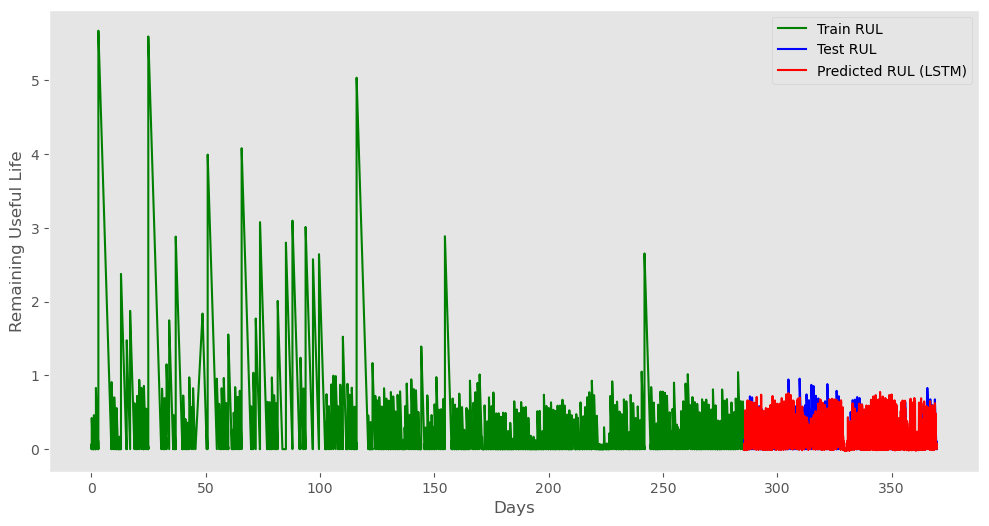

In [146]:
plt.figure(figsize=(12, 6))
plt.plot(days_train, train_inv1, 'g', label="Train RUL")
plt.plot(days_test, test_inv1, 'b', label="Test RUL") # marker='.',
plt.plot(days_test, lstm_y_pred_invee[:, 0], 'r', label="Predicted RUL (LSTM)")
plt.ylabel('Remaining Useful Life')
plt.xlabel('Days')
plt.legend()
plt.show()

In [147]:
lstm_sub_y_pred_invee = pd.DataFrame(lstm_y_pred_invee[:, 0])

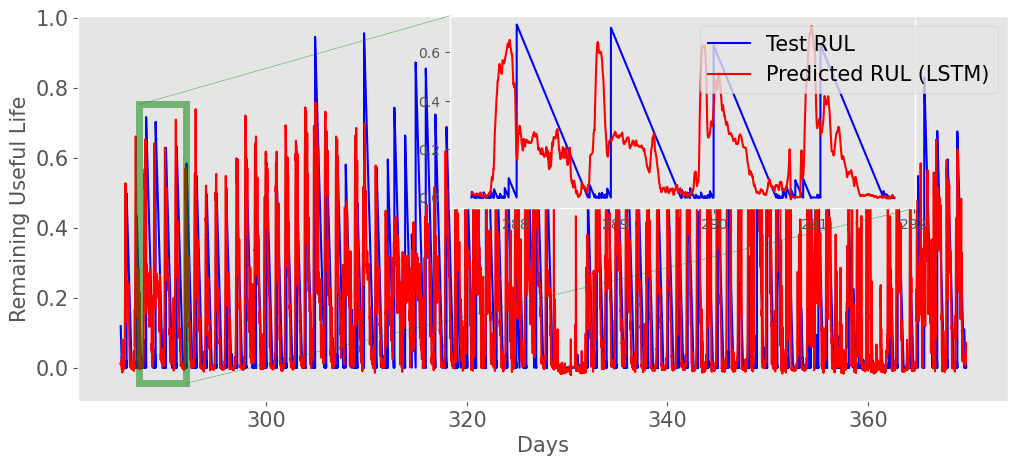

In [148]:
fig, ax = plt.subplots(figsize=(12, 5))

# Main plot
# ax.plot(days_train, train_inv1, color='green', label='Train RUL')
ax.plot(days_test, test_inv1, color='blue', label='Test RUL')
ax.plot(days_test, lstm_sub_y_pred_invee, color='red', label='Predicted RUL (LSTM)')

# Zoomed-in section on test data only
x_zoom = days_test[3000:9000]
test1 = test_inv1.iloc[3000:9000]
lstm1 = lstm_sub_y_pred_invee.iloc[3000:9000]

zm = ax.inset_axes([0.4, 0.5, 0.5, 0.5])
zm.plot(x_zoom, test1, color='blue')
zm.plot(x_zoom, lstm1, color='red')

# Indicate zoomed area correctly on test portion
ax.indicate_inset_zoom(zm, edgecolor='green', lw=5)

plt.xticks(size = 15)
plt.yticks(size = 15)
plt.ylabel('Remaining Useful Life', size = 15)
plt.xlabel('Days', size = 15)
plt.legend(fontsize = 15)
plt.show()

### CNN-LSTM

In [149]:
cnnlstm_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    Conv1D(filters=128, kernel_size=5, activation='relu', padding='same'),
    BatchNormalization(),
    Dropout(0.2),
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    
    Bidirectional(LSTM(64, return_sequences=True)),  
    Bidirectional(LSTM(32, return_sequences=False)),  
    
    Dense(50, activation='relu'),
    Dropout(0.2),
    Dense(120) # ,activation='linear'
])

cnnlstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
cnnlstm_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_7 (Conv1D)               │ (None, 120, 64)        │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 120, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 120, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 120, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 120, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 120, 64)        │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 120, 128)       │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 50)             │         3,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 120)            │         6,120 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,730 (721.60 KB)

 Trainable params: 184,346 (720.10 KB)

 Non-trainable params: 384 (1.50 KB)

In [150]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
ts = time.time()
cnnlstm_history = cnnlstm_model.fit(
                    X_train, 
                    y_train, 
                    epochs=50, 
                    batch_size=32, 
                    validation_split=0.1,
                    shuffle=True,
                    callbacks=[early_stopping]
                    )
print("Training time:", time.time() - ts)

Epoch 1/50
10184/10184 ━━━━━━━━━━━━━━━━━━━━ 1132s 111ms/step - loss: 0.5271 - mae: 0.5527 - val_loss: 0.3115 - val_mae: 0.3676
Epoch 2/50
10184/10184 ━━━━━━━━━━━━━━━━━━━━ 1115s 110ms/step - loss: 0.4169 - mae: 0.4737 - val_loss: 0.3329 - val_mae: 0.3684
Epoch 3/50
10184/10184 ━━━━━━━━━━━━━━━━━━━━ 1126s 111ms/step - loss: 0.3429 - mae: 0.4224 - val_loss: 0.3579 - val_mae: 0.3931
Epoch 4/50
10184/10184 ━━━━━━━━━━━━━━━━━━━━ 1122s 110ms/step - loss: 0.2695 - mae: 0.3695 - val_loss: 0.3708 - val_mae: 0.3879
Epoch 5/50
10184/10184 ━━━━━━━━━━━━━━━━━━━━ 987s 97ms/step - loss: 0.2138 - mae: 0.3260 - val_loss: 0.3982 - val_mae: 0.4078
Epoch 6/50
10184/10184 ━━━━━━━━━━━━━━━━━━━━ 987s 97ms/step - loss: 0.1728 - mae: 0.2921 - val_loss: 0.3954 - val_mae: 0.4030
Training time: 6486.703773260117


In [151]:
cnnlstm_y_pred = cnnlstm_model.predict(X_test)
cnnlstm_y_pred_train = cnnlstm_model.predict(X_train)

3770/3770 ━━━━━━━━━━━━━━━━━━━━ 87s 23ms/step
11316/11316 ━━━━━━━━━━━━━━━━━━━━ 262s 23ms/step


### Model validation on test set - CNN-LSTM

In [152]:
# Make sure true_vals and pred_vals have shape (n_samples, 120)
# true_vals = y_test[3000:9001, :]       # shape: (6001, 120)
pred_vals_cnnlstm = cnnlstm_y_pred[3000:9001, :]   # shape: (6001, 120)

# Per-output MSE, MAE, RMSE
mse_per_output_cnnlstm = np.mean((true_vals - pred_vals_cnnlstm) ** 2, axis=0)
mae_per_output_cnnlstm = np.mean(np.abs(true_vals - pred_vals_cnnlstm), axis=0)
rmse_per_output_cnnlstm = np.sqrt(mse_per_output_cnnlstm)

# R2 score per output
r2_per_output_cnnlstm = [r2_score(true_vals[:, i], pred_vals_cnnlstm[:, i]) for i in range(true_vals.shape[1])]

# Average metrics across all outputs
mse_cnnlstm = mse_per_output_cnnlstm.mean()
mae_cnnlstm = mae_per_output_cnnlstm.mean()
rmse_cnnlstm = rmse_per_output_cnnlstm.mean()
r2_cnnlstm = np.mean(r2_per_output_cnnlstm)

# Print summary
print(f"Average MSE: {mse_cnnlstm:.4f}")
print("-----------------------------------")
print(f"Average MAE: {mae_cnnlstm:.4f}")
print("-----------------------------------")
print(f"Average RMSE: {rmse_cnnlstm:.4f}")
print("-----------------------------------")
print(f"Average R²: {r2_cnnlstm:.4f}")

Average MSE: 0.1521
-----------------------------------
Average MAE: 0.2435
-----------------------------------
Average RMSE: 0.3900
-----------------------------------
Average R²: 0.7929


### Plots - CNN-LSTM

In [153]:
# First transformer
cnnlstm_y_pred_inve = np.zeros_like(cnnlstm_y_pred)
for i in range(cnnlstm_y_pred.shape[1]):
    cnnlstm_y_pred_inve[:, i] = scaler_target.inverse_transform(cnnlstm_y_pred[:, i].reshape(-1, 1)).flatten()

# Second transformer
cnnlstm_y_pred_invee = np.zeros_like(cnnlstm_y_pred_inve)
for i in range(cnnlstm_y_pred_inve.shape[1]):
    cnnlstm_y_pred_invee[:, i] = trf4.inverse_transform(cnnlstm_y_pred_inve[:, i].reshape(-1, 1)).flatten()

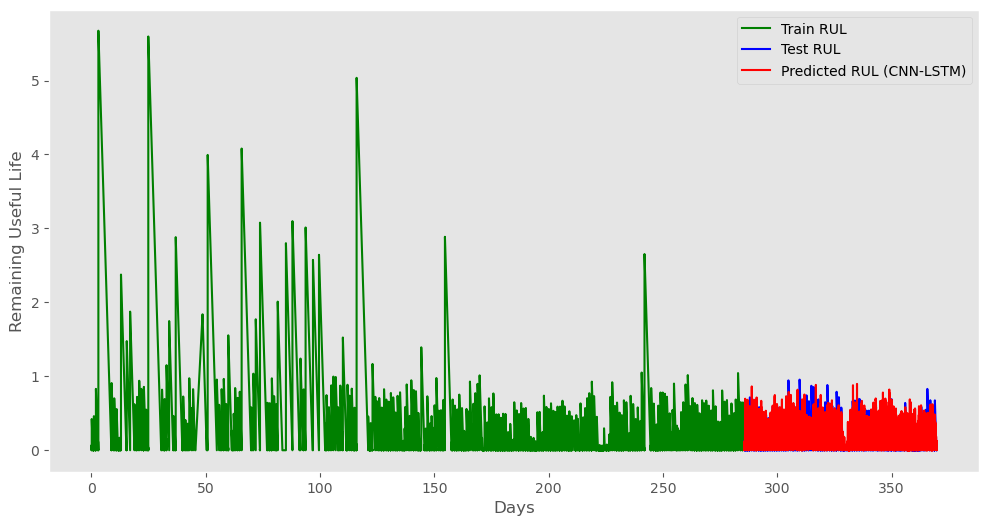

In [154]:
plt.figure(figsize=(12, 6))
plt.plot(days_train, train_inv1, 'g', label="Train RUL")
plt.plot(days_test, test_inv1, 'b', label="Test RUL") # marker='.',
plt.plot(days_test, cnnlstm_y_pred_invee[:, 0], 'r', label="Predicted RUL (CNN-LSTM)")
plt.ylabel('Remaining Useful Life')
plt.xlabel('Days')
plt.legend()
plt.show()

In [155]:
cnnlstm_sub_y_pred_invee = pd.DataFrame(cnnlstm_y_pred_invee[:, 0])

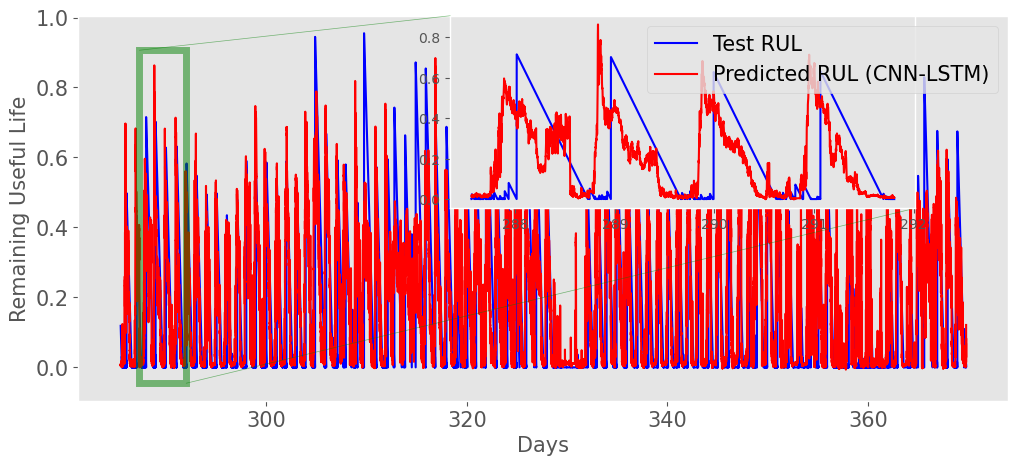

In [162]:
fig, ax = plt.subplots(figsize=(12, 5))

# Main plot
# ax.plot(days_train, train_inv1, color='green', label='Train RUL')
ax.plot(days_test, test_inv1, color='blue', label='Test RUL')
ax.plot(days_test, cnnlstm_sub_y_pred_invee, color='red', label='Predicted RUL (CNN-LSTM)')

# Zoomed-in section on test data only
x_zoom = days_test[3000:9000]
test1 = test_inv1.iloc[3000:9000]
cnnlstm1 = cnnlstm_sub_y_pred_invee.iloc[3000:9000]

zm = ax.inset_axes([0.4, 0.5, 0.5, 0.5])
zm.plot(x_zoom, test1, color='blue')
zm.plot(x_zoom, cnnlstm1, color='red')

# Indicate zoomed area correctly on test portion
ax.indicate_inset_zoom(zm, edgecolor='green', lw=5)

plt.xticks(size = 15)
plt.yticks(size = 15)
plt.ylabel('Remaining Useful Life', size = 15)
plt.xlabel('Days', size = 15)
plt.legend(fontsize = 15)
plt.show()

### Models architectures

#### CNN

In [157]:
# from graphviz import Digraph

# def visualize_cnn_horizontal():
#     dot = Digraph(format='png')
#     dot.attr(rankdir='LR')  # Set direction from Left to Right (horizontal)

#     # Input Layer
#     dot.node('Input', 'Input\n(Timesteps x Features)', shape='box', style='filled', fillcolor='lightblue')

#     # Conv1D Layers
#     dot.node('Conv1D_1', 'Conv1D\n32 Filters\nKernel: 5\nReLU', shape='box', style='filled', fillcolor='orange')
#     dot.node('Conv1D_2', 'Conv1D\n64 Filters\nKernel: 5\nReLU', shape='box', style='filled', fillcolor='orange')

#     # Flatten Layer
#     dot.node('Flatten', 'Flatten', shape='box', style='filled', fillcolor='red')

#     # Fully Connected Layers
#     dot.node('Dense_1', 'Dense\n10 Units\nReLU', shape='box', style='filled', fillcolor='lightgray')
#     dot.node('Output', 'Dense\n1 Unit\nLinear', shape='box', style='filled', fillcolor='lightgreen')

#     # Connecting layers in a horizontal manner
#     dot.edge('Input', 'Conv1D_1')
#     dot.edge('Conv1D_1', 'Conv1D_2')
#     dot.edge('Conv1D_2', 'Flatten')
#     dot.edge('Flatten', 'Dense_1')
#     dot.edge('Dense_1', 'Output')

#     dot.render('cnn_model_horizontal')
#     return dot

# visualize_cnn_horizontal()

#### LSTM

In [158]:
# from graphviz import Digraph

# def visualize_lstm_horizontal():
#     dot = Digraph(format='png')
#     dot.attr(rankdir='LR')  # Set direction from Left to Right (horizontal)

#     # Input Layer
#     dot.node('Input', 'Input\n(Timesteps x Features)', shape='box', style='filled', fillcolor='lightblue')

#     # LSTM Layers
#     dot.node('LSTM_1', 'LSTM\n100 Units\nReturn Sequences=True', shape='box', style='filled', fillcolor='orange')
#     dot.node('Dropout_1', 'Dropout\n(0.2)', shape='box', style='filled', fillcolor='yellow')

#     dot.node('LSTM_2', 'LSTM\n50 Units\nReturn Sequences=False', shape='box', style='filled', fillcolor='orange')
#     dot.node('Dropout_2', 'Dropout\n(0.001)', shape='box', style='filled', fillcolor='yellow')

#     # Dense Layers
#     dot.node('Dense_1', 'Dense\n25 Units\nReLU', shape='box', style='filled', fillcolor='lightgray')
#     dot.node('Output', 'Dense\n1 Unit\nLinear', shape='box', style='filled', fillcolor='lightgreen')

#     # Connecting layers in a horizontal manner
#     dot.edge('Input', 'LSTM_1')
#     dot.edge('LSTM_1', 'Dropout_1')
#     dot.edge('Dropout_1', 'LSTM_2')
#     dot.edge('LSTM_2', 'Dropout_2')
#     dot.edge('Dropout_2', 'Dense_1')
#     dot.edge('Dense_1', 'Output')

#     dot.render('lstm_model_horizontal')
#     return dot

# visualize_lstm_horizontal()

#### CNN-LSTM

In [159]:
# from graphviz import Digraph

# def visualize_cnnlstm_horizontal():
#     dot = Digraph(format='png')
#     dot.attr(rankdir='LR')  # Set direction from Left to Right (horizontal)

#     # Input Layer
#     dot.node('Input', 'Input\n(Timesteps x Features)', shape='box', style='filled', fillcolor='lightblue')

#     # Conv1D Layers
#     dot.node('Conv1D_1', 'Conv1D\n64 Filters\nKernel: 3\nReLU', shape='box', style='filled', fillcolor='orange')
#     dot.node('BatchNorm_1', 'Batch Normalization', shape='box', style='filled', fillcolor='gray')
#     dot.node('Conv1D_2', 'Conv1D\n128 Filters\nKernel: 5\nReLU', shape='box', style='filled', fillcolor='orange')
#     dot.node('BatchNorm_2', 'Batch Normalization', shape='box', style='filled', fillcolor='gray')
#     dot.node('Dropout_1', 'Dropout\n(0.2)', shape='box', style='filled', fillcolor='yellow')
#     dot.node('Conv1D_3', 'Conv1D\n64 Filters\nKernel: 3\nReLU', shape='box', style='filled', fillcolor='orange')

#     # Bidirectional LSTM Layers
#     dot.node('BiLSTM_1', 'Bidirectional LSTM\n64 Units\nReturn Sequences=True', shape='box', style='filled', fillcolor='lightcoral')
#     dot.node('BiLSTM_2', 'Bidirectional LSTM\n32 Units\nReturn Sequences=False', shape='box', style='filled', fillcolor='lightcoral')

#     # Dense Layer and Dropout
#     dot.node('Dense_1', 'Dense\n50 Units\nReLU', shape='box', style='filled', fillcolor='lightgray')
#     dot.node('Dropout_2', 'Dropout\n(0.2)', shape='box', style='filled', fillcolor='yellow')

#     # Output Layer
#     dot.node('Output', 'Dense\n1 Unit\nLinear', shape='box', style='filled', fillcolor='lightgreen')

#     # Connecting layers in a horizontal manner
#     dot.edge('Input', 'Conv1D_1')
#     dot.edge('Conv1D_1', 'BatchNorm_1')
#     dot.edge('BatchNorm_1', 'Conv1D_2')
#     dot.edge('Conv1D_2', 'BatchNorm_2')
#     dot.edge('BatchNorm_2', 'Dropout_1')
#     dot.edge('Dropout_1', 'Conv1D_3')
#     dot.edge('Conv1D_3', 'BiLSTM_1')
#     dot.edge('BiLSTM_1', 'BiLSTM_2')
#     dot.edge('BiLSTM_2', 'Dense_1')
#     dot.edge('Dense_1', 'Dropout_2')
#     dot.edge('Dropout_2', 'Output')

#     dot.render('cnnlstm_model_horizontal')
#     return dot

# visualize_cnnlstm_horizontal()

#### LSTM Reverse

In [160]:
# from graphviz import Digraph

# def visualize_lstmae_horizontal():
#     dot = Digraph(format='png')
#     dot.attr(rankdir='LR')  # Set direction from Left to Right (horizontal)

#     # Input Layer
#     dot.node('Input', 'Input\n(Timesteps x Features)', shape='box', style='filled', fillcolor='lightblue')

#     # LSTM Layers
#     dot.node('LSTM_1', 'LSTM\n128 Units\nReLU\nReturn Sequences=True', shape='box', style='filled', fillcolor='orange')
#     dot.node('LSTM_2', 'LSTM\n64 Units\nReLU\nReturn Sequences=False', shape='box', style='filled', fillcolor='orange')

#     # Dropout Layers
#     dot.node('Dropout_1', 'Dropout\n(0.001)', shape='box', style='filled', fillcolor='yellow')
#     dot.node('Dropout_2', 'Dropout\n(0.001)', shape='box', style='filled', fillcolor='yellow')

#     # Dense Layers
#     dot.node('Dense_1', 'Dense\n64 Units\nReLU', shape='box', style='filled', fillcolor='lightgray')
#     dot.node('Dense_2', 'Dense\n128 Units\nReLU', shape='box', style='filled', fillcolor='lightgray')
#     dot.node('Output', 'Dense\n1 Unit\nLinear', shape='box', style='filled', fillcolor='lightgreen')

#     # Connecting layers in a horizontal manner
#     dot.edge('Input', 'LSTM_1')
#     dot.edge('LSTM_1', 'LSTM_2')
#     dot.edge('LSTM_2', 'Dropout_1')
#     dot.edge('Dropout_1', 'Dense_1')
#     dot.edge('Dense_1', 'Dense_2')
#     dot.edge('Dense_2', 'Dropout_2')
#     dot.edge('Dropout_2', 'Output')

#     dot.render('lstmae_model_horizontal')
#     return dot

# visualize_lstmae_horizontal()

In [161]:
# Convert from .ipynb into .py
# !jupyter nbconvert --to script turing_ready_paper3_rul_vib_cnn_lstm_cnnlstm_lstmae.ipynb